# Evaluate Return Prediction Strategies

This notebook loads saved prediction outputs for the neural network, LASSO, Ridge, random forest, SVR, and an OLS baseline inherited from the RF notebook, computes prediction metrics using the evaluation functions from `random_forest.Rmd`, and evaluates portfolio performance alongside an equal-weight long-only baseline built from `data_ml.RData`.

The analysis is run separately for:

- `in_sample`: the pre-holdout walk-forward predictions
- `holdout`: the strict out-of-sample predictions

At the end, the notebook produces a single comparison table of performance metrics across all predictive strategies plus the benchmark baseline.


In [97]:
# Setup
required_packages <- c("tidyverse", "lubridate")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]

if (length(missing_packages) > 0) {
  stop(
    "Install the missing packages before running this notebook: ",
    paste(missing_packages, collapse = ", ")
  )
}

invisible(lapply(required_packages, library, character.only = TRUE))
options(dplyr.summarise.inform = FALSE)


In [98]:
# Configuration constants
DATA_ML_PATH <- "data_ml.RData"
NN_PREDICTIONS_PATH <- "preds/nn_preds.rds"
RF_PREDICTIONS_PATH <- "preds/rf_preds.rds"
SVR_PREDICTIONS_PATH <- "preds/svr_preds.rds"
LASSO_OUTPUTS_PATH <- "lasso_outputs.RData"
RIDGE_OUTPUTS_PATH <- "ridge_outputs.RData"
HOLDOUT_START <- as.Date("2014-01-15")
SAMPLE_LABELS <- c("in_sample", "holdout")
MODEL_STRATEGY_LABELS <- c("neural_network", "lasso", "ridge", "random_forest", "svr", "ols_baseline")
BASELINE_STRATEGY_LABEL <- "EW_long_only_baseline"
PORTFOLIO_STRATEGY_LABELS <- c(MODEL_STRATEGY_LABELS, BASELINE_STRATEGY_LABEL)
LONG_SHORT_QUANTILE <- 0.10
ANNUALISE_FACTOR <- 12
TC_PER_UNIT_TURNOVER <- 0  # set to 0.005 for a 50 bps per-unit-turnover assumption


In [99]:
# Load predictions for each strategy
load_linear_predictions <- function(path, prediction_col, strategy_name) {
  model_env <- new.env(parent = emptyenv())
  load(path, envir = model_env)

  if (!exists("oos_predictions", envir = model_env)) {
    stop("File does not contain an 'oos_predictions' object: ", path)
  }

  get("oos_predictions", envir = model_env) %>%
    transmute(
      stock_id = stock_id,
      date = as.Date(date),
      actual_return = y_true,
      predicted_return = .data[[prediction_col]],
      sample = if_else(date >= HOLDOUT_START, "holdout", "in_sample"),
      strategy = strategy_name
    )
}

load_rds_predictions <- function(path, actual_col, prediction_col, strategy_name) {
  preds <- readRDS(path)

  preds %>%
    transmute(
      stock_id = stock_id,
      date = lubridate::ceiling_date(as.Date(date), "month") - lubridate::days(1),
      actual_return = .data[[actual_col]],
      predicted_return = .data[[prediction_col]],
      sample = if_else(date >= HOLDOUT_START, "holdout", "in_sample"),
      strategy = strategy_name
    )
}

load_equal_weight_panel <- function(path, strategy_name) {
  model_env <- new.env(parent = emptyenv())
  load(path, envir = model_env)

  if (!exists("data_ml", envir = model_env)) {
    stop("File does not contain a 'data_ml' object: ", path)
  }

  get("data_ml", envir = model_env) %>%
    transmute(
      stock_id = stock_id,
      date = as.Date(date),
      actual_return = R1M_Usd,
      sample = if_else(as.Date(date) >= HOLDOUT_START, "holdout", "in_sample"),
      strategy = strategy_name
    ) %>%
    filter(
      sample %in% SAMPLE_LABELS,
      !is.na(actual_return)
    )
}

nn_preds <- readRDS(NN_PREDICTIONS_PATH) %>%
  transmute(
    stock_id = stock_id,
    date = as.Date(date),
    actual_return = actual_return,
    predicted_return = predicted_return,
    sample = as.character(sample),
    strategy = "neural_network"
  )

rf_preds <- load_rds_predictions(
  path = RF_PREDICTIONS_PATH,
  actual_col = "actual",
  prediction_col = "pred_rf",
  strategy_name = "random_forest"
)

svr_preds <- load_rds_predictions(
  path = SVR_PREDICTIONS_PATH,
  actual_col = "actual",
  prediction_col = "pred_svr",
  strategy_name = "svr"
)

ols_preds <- load_rds_predictions(
  path = RF_PREDICTIONS_PATH,
  actual_col = "actual",
  prediction_col = "pred_ols",
  strategy_name = "ols_baseline"
)

lasso_preds <- load_linear_predictions(
  path = LASSO_OUTPUTS_PATH,
  prediction_col = "y_pred_lasso",
  strategy_name = "lasso"
)

ridge_preds <- load_linear_predictions(
  path = RIDGE_OUTPUTS_PATH,
  prediction_col = "y_pred_ridge",
  strategy_name = "ridge"
)

equal_weight_panel <- load_equal_weight_panel(
  path = DATA_ML_PATH,
  strategy_name = BASELINE_STRATEGY_LABEL
)

all_preds <- bind_rows(nn_preds, rf_preds, svr_preds, ols_preds, lasso_preds, ridge_preds) %>%
  filter(sample %in% SAMPLE_LABELS) %>%
  arrange(strategy, sample, date, stock_id)

common_model_date_range <- all_preds %>%
  group_by(strategy) %>%
  summarise(start_date = min(date, na.rm = TRUE), end_date = max(date, na.rm = TRUE), .groups = "drop") %>%
  summarise(
    overlap_start = max(start_date, na.rm = TRUE),
    overlap_end = min(end_date, na.rm = TRUE)
  )

overlap_start <- common_model_date_range$overlap_start[[1]]
overlap_end <- common_model_date_range$overlap_end[[1]]

all_preds <- all_preds %>%
  filter(date >= overlap_start, date <= overlap_end)

equal_weight_panel <- equal_weight_panel %>%
  filter(date >= overlap_start, date <= overlap_end)

required_columns <- c("stock_id", "date", "actual_return", "predicted_return", "sample", "strategy")
missing_columns <- setdiff(required_columns, names(all_preds))
if (length(missing_columns) > 0) {
  stop("Combined prediction table is missing required columns: ", paste(missing_columns, collapse = ", "))
}

all_preds %>%
  count(strategy, sample, name = "rows")


strategy,sample,rows
<chr>,<chr>,<int>
lasso,holdout,70208
lasso,in_sample,128880
neural_network,holdout,70208
neural_network,in_sample,128880
ols_baseline,holdout,70173
ols_baseline,in_sample,128349
random_forest,holdout,70173
random_forest,in_sample,128349
ridge,holdout,70208


In [100]:
head(all_preds)


stock_id,date,actual_return,predicted_return,sample,strategy
<int>,<date>,<dbl>,<dbl>,<chr>,<chr>
1,2014-01-31,0.153,-0.001101714,holdout,lasso
2,2014-01-31,0.180,0.012996520,holdout,lasso
3,2014-01-31,-0.007,0.015415566,holdout,lasso
4,2014-01-31,0.045,0.010218171,holdout,lasso
5,2014-01-31,0.024,0.008420660,holdout,lasso
6,2014-01-31,0.013,0.007699112,holdout,lasso


## Evaluation Functions

These are the same core performance functions used in `random_forest.Rmd`, with a few lightweight helpers added so we can evaluate prediction files and long/short portfolio returns consistently across all five strategies.


In [101]:
compute_mse <- function(y_true, y_pred) {
  mse <- mean((y_true - y_pred)^2, na.rm = TRUE)
  cat("MSE (total):", round(mse, 6), "\n")
  cat("Note: the cross-term between realized and predicted returns is often most informative for portfolios\n")
  invisible(mse)
}

compute_oos_r2 <- function(y_true, y_pred, include_mean_benchmark = FALSE) {
  numerator <- sum((y_true - y_pred)^2, na.rm = TRUE)
  denominator <- if (include_mean_benchmark) {
    sum((y_true - mean(y_true, na.rm = TRUE))^2, na.rm = TRUE)
  } else {
    sum(y_true^2, na.rm = TRUE)
  }
  r2 <- 1 - (numerator / denominator)
  cat("OOS R2:", round(r2, 4), "\n")
  invisible(r2)
}

compute_hit_ratio <- function(y_true, y_pred) {
  hit_ratio <- mean(sign(y_pred) == sign(y_true), na.rm = TRUE)
  cat("Hit ratio:", round(hit_ratio, 4), "\n")
  invisible(hit_ratio)
}

compute_sharpe <- function(returns_portfolio, returns_benchmark = NULL,
                           tc_per_unit_turnover = 0,
                           avg_turnover = 0,
                           annualise_factor = 12) {
  mu <- mean(returns_portfolio, na.rm = TRUE)
  sigma <- sd(returns_portfolio, na.rm = TRUE)

  sharpe_raw <- mu / sigma
  sharpe_tc <- (mu - tc_per_unit_turnover * avg_turnover) / sigma
  sharpe_raw_ann <- sharpe_raw * sqrt(annualise_factor)
  sharpe_tc_ann <- sharpe_tc * sqrt(annualise_factor)

  cat("Sharpe ratio diagnostics:\n")
  cat("  Avg monthly return   :", round(mu, 4), "\n")
  cat("  Monthly volatility   :", round(sigma, 4), "\n")
  cat("  Sharpe (monthly)     :", round(sharpe_raw, 4), "\n")
  cat("  Sharpe (annualised)  :", round(sharpe_raw_ann, 4), "\n")
  cat("  Avg turnover         :", round(avg_turnover, 4), "\n")
  cat("  TC per unit turnover :", tc_per_unit_turnover, "\n")
  cat("  TC-adj Sharpe (ann)  :", round(sharpe_tc_ann, 4), "\n")

  if (!is.null(returns_benchmark)) {
    excess <- returns_portfolio - returns_benchmark
    info_ratio <- mean(excess, na.rm = TRUE) / sd(excess, na.rm = TRUE)
    cat("  Information ratio    :", round(info_ratio * sqrt(annualise_factor), 4), "\n")
    cat("  Tracking error (ann) :", round(sd(excess, na.rm = TRUE) * sqrt(annualise_factor), 4), "\n")
  }

  invisible(c(
    sharpe_raw = sharpe_raw,
    sharpe_raw_ann = sharpe_raw_ann,
    sharpe_tc = sharpe_tc,
    sharpe_tc_ann = sharpe_tc_ann
  ))
}

compute_turnover_series <- function(weights_matrix, asset_returns_matrix) {
  if (nrow(weights_matrix) != nrow(asset_returns_matrix) ||
      ncol(weights_matrix) != ncol(asset_returns_matrix)) {
    stop("weights_matrix and asset_returns_matrix must have identical dimensions.")
  }

  n_periods <- nrow(weights_matrix)

  if (n_periods == 0) {
    return(list(turnover = numeric(), avg_turnover = NA_real_))
  }

  turnover <- rep(0, n_periods)

  if (n_periods >= 2) {
    for (t in 2:n_periods) {
      prior_w <- weights_matrix[t - 1, ] * (1 + asset_returns_matrix[t, ])
      target_gross <- sum(abs(weights_matrix[t, ]), na.rm = TRUE)
      prior_gross <- sum(abs(prior_w), na.rm = TRUE)

      if (is.na(prior_gross) || prior_gross == 0) {
        prior_w <- rep(0, length(prior_w))
      } else {
        prior_w <- prior_w / prior_gross * target_gross
      }

      turnover[t] <- sum(abs(weights_matrix[t, ] - prior_w), na.rm = TRUE)
    }
  }

  avg_turnover <- if (n_periods >= 2) mean(turnover[-1], na.rm = TRUE) else 0

  cat("Portfolio turnover:\n")
  cat("  Average (per rebalancing):", round(avg_turnover, 4), "\n")
  cat("  Annualised (×12)         :", round(avg_turnover * 12, 4), "\n")

  list(turnover = turnover, avg_turnover = avg_turnover)
}

construct_long_short_portfolio_bundle <- function(prediction_df, long_short_quantile = 0.10) {
  benchmark_returns <- prediction_df %>%
    group_by(date) %>%
    summarise(benchmark_return = mean(actual_return, na.rm = TRUE), .groups = "drop")

  long_positions <- prediction_df %>%
    group_by(date) %>%
    arrange(desc(predicted_return), stock_id, .by_group = TRUE) %>%
    mutate(n_select = pmax(floor(n() * long_short_quantile), 1L)) %>%
    filter(row_number() <= first(n_select)) %>%
    mutate(side = "long") %>%
    ungroup()

  short_positions <- prediction_df %>%
    group_by(date) %>%
    arrange(predicted_return, stock_id, .by_group = TRUE) %>%
    mutate(n_select = pmax(floor(n() * long_short_quantile), 1L)) %>%
    filter(row_number() <= first(n_select)) %>%
    mutate(side = "short") %>%
    ungroup()

  selected_positions <- bind_rows(long_positions, short_positions)

  portfolio_df <- selected_positions %>%
    group_by(date, side) %>%
    summarise(ret = mean(actual_return, na.rm = TRUE), n_names = n(), .groups = "drop") %>%
    select(date, side, ret) %>%
    tidyr::pivot_wider(names_from = side, values_from = ret) %>%
    mutate(ls_return = long - short) %>%
    left_join(benchmark_returns, by = "date") %>%
    arrange(date)

  weight_df <- prediction_df %>%
    select(date, stock_id, actual_return) %>%
    left_join(
      long_positions %>% select(date, stock_id) %>% mutate(in_long = TRUE),
      by = c("date", "stock_id")
    ) %>%
    left_join(
      short_positions %>% select(date, stock_id) %>% mutate(in_short = TRUE),
      by = c("date", "stock_id")
    ) %>%
    group_by(date) %>%
    mutate(
      in_long = tidyr::replace_na(in_long, FALSE),
      in_short = tidyr::replace_na(in_short, FALSE),
      n_long = sum(in_long, na.rm = TRUE),
      n_short = sum(in_short, na.rm = TRUE),
      weight = dplyr::case_when(
        in_long ~ 1 / n_long,
        in_short ~ -1 / n_short,
        TRUE ~ 0
      )
    ) %>%
    ungroup()

  weights_wide <- weight_df %>%
    select(date, stock_id, weight) %>%
    tidyr::pivot_wider(names_from = stock_id, values_from = weight, values_fill = 0) %>%
    arrange(date)

  returns_wide <- weight_df %>%
    select(date, stock_id, actual_return) %>%
    tidyr::pivot_wider(names_from = stock_id, values_from = actual_return, values_fill = 0) %>%
    arrange(date)

  common_cols <- intersect(names(weights_wide)[-1], names(returns_wide)[-1])

  list(
    portfolio = portfolio_df,
    weights_matrix = as.matrix(weights_wide[, common_cols, drop = FALSE]),
    asset_returns_matrix = as.matrix(returns_wide[, common_cols, drop = FALSE])
  )
}

construct_equal_weight_long_only_bundle <- function(panel_df) {
  portfolio_df <- panel_df %>%
    group_by(date) %>%
    summarise(
      long = mean(actual_return, na.rm = TRUE),
      short = 0,
      ls_return = long,
      benchmark_return = mean(actual_return, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(date)

  weight_df <- panel_df %>%
    group_by(date) %>%
    mutate(weight = 1 / dplyr::n()) %>%
    ungroup()

  weights_wide <- weight_df %>%
    select(date, stock_id, weight) %>%
    tidyr::pivot_wider(names_from = stock_id, values_from = weight, values_fill = 0) %>%
    arrange(date)

  returns_wide <- weight_df %>%
    select(date, stock_id, actual_return) %>%
    tidyr::pivot_wider(names_from = stock_id, values_from = actual_return, values_fill = 0) %>%
    arrange(date)

  common_cols <- intersect(names(weights_wide)[-1], names(returns_wide)[-1])

  list(
    portfolio = portfolio_df,
    weights_matrix = as.matrix(weights_wide[, common_cols, drop = FALSE]),
    asset_returns_matrix = as.matrix(returns_wide[, common_cols, drop = FALSE])
  )
}

add_transaction_costs <- function(ls_df, weights_matrix, asset_returns_matrix, tc_per_unit_turnover) {
  turnover_info <- compute_turnover_series(weights_matrix, asset_returns_matrix)
  ls_df %>%
    mutate(
      turnover = turnover_info$turnover,
      transaction_cost = tc_per_unit_turnover * turnover,
      ls_return_tc = ls_return - transaction_cost
    )
}

summarise_prediction_metrics <- function(prediction_df, strategy_name, sample_name) {
  cat("---", strategy_name, "|", sample_name, "prediction performance ---\n")

  mse <- compute_mse(prediction_df$actual_return, prediction_df$predicted_return)
  hit_ratio <- compute_hit_ratio(prediction_df$actual_return, prediction_df$predicted_return)
  oos_r2 <- compute_oos_r2(
    prediction_df$actual_return,
    prediction_df$predicted_return,
    include_mean_benchmark = TRUE
  )

  tibble(
    strategy = strategy_name,
    sample = sample_name,
    observations = nrow(prediction_df),
    mse = mse,
    hit_ratio = hit_ratio,
    oos_r2 = oos_r2
  )
}

summarise_portfolio_metrics <- function(ls_df, strategy_name, sample_name, weights_matrix, asset_returns_matrix) {
  cat("---", strategy_name, "|", sample_name, "portfolio performance ---\n")

  turnover_info <- compute_turnover_series(weights_matrix, asset_returns_matrix)
  avg_turnover <- turnover_info$avg_turnover

  sharpe_stats <- compute_sharpe(
    returns_portfolio = ls_df$ls_return,
    returns_benchmark = ls_df$benchmark_return,
    tc_per_unit_turnover = TC_PER_UNIT_TURNOVER,
    avg_turnover = avg_turnover,
    annualise_factor = ANNUALISE_FACTOR
  )

  tibble(
    strategy = strategy_name,
    sample = sample_name,
    months = nrow(ls_df),
    avg_turnover = avg_turnover,
    avg_monthly_return = mean(ls_df$ls_return, na.rm = TRUE),
    avg_monthly_return_tc = mean(ls_df$ls_return_tc, na.rm = TRUE),
    monthly_volatility = sd(ls_df$ls_return, na.rm = TRUE),
    monthly_volatility_tc = sd(ls_df$ls_return_tc, na.rm = TRUE),
    annualised_return = mean(ls_df$ls_return, na.rm = TRUE) * ANNUALISE_FACTOR,
    annualised_return_tc = mean(ls_df$ls_return_tc, na.rm = TRUE) * ANNUALISE_FACTOR,
    sharpe_raw = unname(sharpe_stats[["sharpe_raw"]]),
    sharpe_raw_ann = unname(sharpe_stats[["sharpe_raw_ann"]]),
    sharpe_tc = unname(sharpe_stats[["sharpe_tc"]]),
    sharpe_tc_ann = unname(sharpe_stats[["sharpe_tc_ann"]])
  )
}


## Prediction Metrics

This section computes the cross-sectional prediction metrics for each strategy and each sample split.


In [102]:
prediction_metrics <- tidyr::expand_grid(
  strategy = MODEL_STRATEGY_LABELS,
  sample = SAMPLE_LABELS
) %>%
  mutate(
    data = purrr::map2(
      strategy,
      sample,
      ~ all_preds %>% filter(strategy == .x, sample == .y)
    ),
    metrics = purrr::pmap(
      list(data, strategy, sample),
      summarise_prediction_metrics
    )
  ) %>%
  select(metrics) %>%
  tidyr::unnest(metrics)

prediction_metrics


--- neural_network | in_sample prediction performance ---
MSE (total): 0.027927 
Note: the cross-term between realized and predicted returns is often most informative for portfolios
Hit ratio: 0.5399 
OOS R2: -0.0078 
--- neural_network | holdout prediction performance ---
MSE (total): 0.037069 
Note: the cross-term between realized and predicted returns is often most informative for portfolios
Hit ratio: 0.546 
OOS R2: -0.0025 
--- lasso | in_sample prediction performance ---
MSE (total): 0.027715 
Note: the cross-term between realized and predicted returns is often most informative for portfolios
Hit ratio: 0.5362 
OOS R2: -2e-04 
--- lasso | holdout prediction performance ---
MSE (total): 0.03702 
Note: the cross-term between realized and predicted returns is often most informative for portfolios
Hit ratio: 0.532 
OOS R2: -0.0012 
--- ridge | in_sample prediction performance ---
MSE (total): 0.027705 
Note: the cross-term between realized and predicted returns is often most informat

strategy,sample,observations,mse,hit_ratio,oos_r2
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
neural_network,in_sample,128880,0.02792723,0.5399053,-0.0078072801
neural_network,holdout,70208,0.03706859,0.5460346,-0.0024955273
lasso,in_sample,128880,0.02771542,0.5362042,-0.0001636182
lasso,holdout,70208,0.03702010,0.5320334,-0.0011841520
ridge,in_sample,128880,0.02770530,0.5358473,0.0002015459
ridge,holdout,70208,0.03701457,0.5315491,-0.0010345615
random_forest,in_sample,128349,0.03252797,0.4999727,-0.1711406649
random_forest,holdout,70173,0.04069083,0.5280949,-0.1000966567
svr,in_sample,128880,0.03033253,0.5498371,-0.0946070549


## Portfolio Construction

For each predictive strategy and sample split, the notebook forms an equal-weight long/short portfolio by going long the top `LONG_SHORT_QUANTILE` fraction of names by predicted return and short the bottom `LONG_SHORT_QUANTILE` fraction. It also builds an equal-weight long-only baseline using `data_ml.RData`.


In [103]:
model_ls_portfolios <- tidyr::expand_grid(
  strategy = MODEL_STRATEGY_LABELS,
  sample = SAMPLE_LABELS
) %>%
  mutate(
    bundle = purrr::map2(
      strategy,
      sample,
      ~ all_preds %>%
        filter(strategy == .x, sample == .y) %>%
        construct_long_short_portfolio_bundle(long_short_quantile = LONG_SHORT_QUANTILE)
    )
  ) %>%
  transmute(
    strategy,
    sample,
    data = purrr::map(bundle, "portfolio"),
    weights_matrix = purrr::map(bundle, "weights_matrix"),
    asset_returns_matrix = purrr::map(bundle, "asset_returns_matrix")
  )

equal_weight_ls_portfolios <- equal_weight_panel %>%
  group_by(sample) %>%
  tidyr::nest(panel_data = c(stock_id, date, actual_return, strategy)) %>%
  mutate(
    bundle = purrr::map(panel_data, construct_equal_weight_long_only_bundle),
    strategy = BASELINE_STRATEGY_LABEL,
    data = purrr::map(bundle, "portfolio"),
    weights_matrix = purrr::map(bundle, "weights_matrix"),
    asset_returns_matrix = purrr::map(bundle, "asset_returns_matrix")
  ) %>%
  select(strategy, sample, data, weights_matrix, asset_returns_matrix)

ls_portfolios <- bind_rows(model_ls_portfolios, equal_weight_ls_portfolios) %>%
  mutate(
    data = purrr::pmap(
      list(data, weights_matrix, asset_returns_matrix),
      ~ add_transaction_costs(..1, ..2, ..3, tc_per_unit_turnover = TC_PER_UNIT_TURNOVER)
    )
  )

ls_portfolios %>%
  select(strategy, sample, data) %>%
  tidyr::unnest(data) %>%
  arrange(strategy, sample, date) %>%
  group_by(strategy, sample) %>%
  slice_head(n = 3)


Portfolio turnover:
  Average (per rebalancing): 0.851 
  Annualised (×12)         : 10.2118 
Portfolio turnover:
  Average (per rebalancing): 0.7333 
  Annualised (×12)         : 8.7995 
Portfolio turnover:
  Average (per rebalancing): 0.7198 
  Annualised (×12)         : 8.6378 
Portfolio turnover:
  Average (per rebalancing): 0.8194 
  Annualised (×12)         : 9.8326 
Portfolio turnover:
  Average (per rebalancing): 0.6639 
  Annualised (×12)         : 7.9662 
Portfolio turnover:
  Average (per rebalancing): 0.7107 
  Annualised (×12)         : 8.5289 
Portfolio turnover:
  Average (per rebalancing): 2.0832 
  Annualised (×12)         : 24.9983 
Portfolio turnover:
  Average (per rebalancing): 2.2534 
  Annualised (×12)         : 27.0407 
Portfolio turnover:
  Average (per rebalancing): 1.9321 
  Annualised (×12)         : 23.1847 
Portfolio turnover:
  Average (per rebalancing): 1.8488 
  Annualised (×12)         : 22.1852 
Portfolio turnover:
  Average (per rebalancing): 1.1736 

strategy,sample,date,long,short,ls_return,benchmark_return,turnover,transaction_cost,ls_return_tc
<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EW_long_only_baseline,holdout,2014-01-31,0.041238255,0.000000000,4.123826e-02,0.041238255,0.00000000,0,4.123826e-02
EW_long_only_baseline,holdout,2014-02-28,0.008456376,0.000000000,8.456376e-03,0.008456376,0.04725031,0,8.456376e-03
EW_long_only_baseline,holdout,2014-03-31,-0.003793624,0.000000000,-3.793624e-03,-0.003793624,0.05175579,0,-3.793624e-03
EW_long_only_baseline,in_sample,2005-01-31,0.037231993,0.000000000,3.723199e-02,0.037231993,0.00000000,0,3.723199e-02
EW_long_only_baseline,in_sample,2005-02-28,-0.023657454,0.000000000,-2.365745e-02,-0.023657454,0.05698458,0,-2.365745e-02
EW_long_only_baseline,in_sample,2005-03-31,-0.040958961,0.000000000,-4.095896e-02,-0.040958961,0.07043822,0,-4.095896e-02
lasso,holdout,2014-01-31,0.048605042,0.051756303,-3.151261e-03,0.041238255,0.00000000,0,-3.151261e-03
lasso,holdout,2014-02-28,0.019243697,-0.005974790,2.521849e-02,0.008456376,0.68148062,0,2.521849e-02
lasso,holdout,2014-03-31,-0.003243697,-0.002848739,-3.949580e-04,-0.003793624,1.04346098,0,-3.949580e-04


## Portfolio Metrics

This section evaluates the long/short portfolios for each predictive strategy and the equal-weight long-only baseline for each sample split, including turnover and transaction-cost-adjusted return and Sharpe metrics.


In [104]:
portfolio_metrics <- ls_portfolios %>%
  mutate(
    metrics = purrr::pmap(
      list(data, strategy, sample, weights_matrix, asset_returns_matrix),
      summarise_portfolio_metrics
    )
  ) %>%
  select(metrics) %>%
  tidyr::unnest(metrics)

portfolio_metrics


--- neural_network | in_sample portfolio performance ---
Portfolio turnover:
  Average (per rebalancing): 0.851 
  Annualised (×12)         : 10.2118 
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0164 
  Monthly volatility   : 0.0553 
  Sharpe (monthly)     : 0.2967 
  Sharpe (annualised)  : 1.0277 
  Avg turnover         : 0.851 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 1.0277 
  Information ratio    : 0.2534 
  Tracking error (ann) : 0.2098 
--- neural_network | holdout portfolio performance ---
Portfolio turnover:
  Average (per rebalancing): 0.7333 
  Annualised (×12)         : 8.7995 
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0162 
  Monthly volatility   : 0.0705 
  Sharpe (monthly)     : 0.2301 
  Sharpe (annualised)  : 0.797 
  Avg turnover         : 0.7333 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 0.797 
  Information ratio    : 0.4387 
  Tracking error (ann) : 0.1803 
--- lasso | in_sample portfolio performance ---
Portfolio turnover:

strategy,sample,months,avg_turnover,avg_monthly_return,avg_monthly_return_tc,monthly_volatility,monthly_volatility_tc,annualised_return,annualised_return_tc,sharpe_raw,sharpe_raw_ann,sharpe_tc,sharpe_tc_ann
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
neural_network,in_sample,108,0.85097981,0.0164196234,0.0164196234,0.05534431,0.05534431,0.197035481,0.197035481,0.296681326,1.02773426,0.296681326,1.02773426
neural_network,holdout,60,0.73329398,0.0162103589,0.0162103589,0.07046073,0.07046073,0.194524307,0.194524307,0.230062324,0.79695927,0.230062324,0.79695927
lasso,in_sample,108,0.71981365,0.0243134921,0.0243134921,0.06911994,0.06911994,0.291761905,0.291761905,0.351757997,1.21852545,0.351757997,1.21852545
lasso,holdout,60,0.81938309,0.0121679604,0.0121679604,0.06346211,0.06346211,0.146015525,0.146015525,0.191735841,0.66419244,0.191735841,0.66419244
ridge,in_sample,108,0.66385137,0.0254509026,0.0254509026,0.06716499,0.06716499,0.305410831,0.305410831,0.378931066,1.31265572,0.378931066,1.31265572
ridge,holdout,60,0.71074360,0.0178922270,0.0178922270,0.06603421,0.06603421,0.214706724,0.214706724,0.270953919,0.93861191,0.270953919,0.93861191
random_forest,in_sample,108,2.08318777,0.0088659496,0.0088659496,0.04276392,0.04276392,0.106391395,0.106391395,0.207323142,0.71818843,0.207323142,0.71818843
random_forest,holdout,60,2.25338848,-0.0001176230,-0.0001176230,0.02805655,0.02805655,-0.001411476,-0.001411476,-0.004192355,-0.01452274,-0.004192355,-0.01452274
svr,in_sample,108,1.93206248,0.0008254746,0.0008254746,0.03083786,0.03083786,0.009905696,0.009905696,0.026768219,0.09272783,0.026768219,0.09272783


## Fama-French 5-Factor Decomposition

This section downloads the monthly U.S. Fama-French 5 factors from the Ken French Data Library, aligns them to the long/short portfolio returns, and estimates a separate factor model for each strategy and sample split. If the factor file cannot be downloaded, the notebook will skip this section gracefully rather than failing the full evaluation.


In [105]:
FF5_URL <- "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
FF5_ZIP_MEMBER <- "F-F_Research_Data_5_Factors_2x3.csv"

load_ff5_data <- function(url = FF5_URL, zip_member = FF5_ZIP_MEMBER) {
  ff5_temp <- tempfile(fileext = ".zip")

  ff5_raw <- tryCatch(
    {
      download.file(url, ff5_temp, quiet = TRUE, mode = "wb")
      readr::read_csv(unz(ff5_temp, zip_member), skip = 3, show_col_types = FALSE)
    },
    error = function(e) {
      message("Skipping FF5 decomposition because factor download failed: ", conditionMessage(e))
      NULL
    }
  )

  if (is.null(ff5_raw)) {
    return(NULL)
  }

  ff5_raw %>%
    rename(date_raw = 1) %>%
    mutate(date_raw = as.character(date_raw)) %>%
    filter(nchar(date_raw) == 6) %>%
    mutate(
      # Align factor dates to month-end so they match the portfolio return dates.
      date = lubridate::ceiling_date(lubridate::ymd(paste0(date_raw, "01")), "month") - lubridate::days(1),
      Mkt_RF = as.numeric(`Mkt-RF`) / 100,
      SMB = as.numeric(SMB) / 100,
      HML = as.numeric(HML) / 100,
      RMW = as.numeric(RMW) / 100,
      CMA = as.numeric(CMA) / 100,
      RF = as.numeric(RF) / 100
    ) %>%
    select(date, Mkt_RF, SMB, HML, RMW, CMA, RF)
}

ff5_data <- load_ff5_data()

if (!is.null(ff5_data)) {
  ff5_data %>% head()
} else {
  tibble(note = "FF5 data unavailable in this environment; decomposition skipped.")
}


New names:
• `` -> `...1`
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


date,Mkt_RF,SMB,HML,RMW,CMA,RF
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027
1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025
1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027
1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029
1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027
1963-12-31,0.0183,-0.0189,-0.0021,0.0012,-0.0025,0.0029


In [106]:
compute_ff5_decomposition <- function(ls_df, strategy_name, sample_name) {
  ff5_joined <- ls_df %>%
    left_join(ff5_data, by = "date") %>%
    drop_na(Mkt_RF, SMB, HML, RMW, CMA, RF) %>%
    mutate(
      excess_return = ls_return - RF,
      excess_return_tc = ls_return_tc - RF
    )

  if (nrow(ff5_joined) == 0) {
    stop(
      "No overlapping month-end dates between the portfolio returns and FF5 factors for strategy '",
      strategy_name,
      "' and sample '",
      sample_name,
      "'."
    )
  }

  ff5_fit <- lm(excess_return ~ Mkt_RF + SMB + HML + RMW + CMA, data = ff5_joined)
  ff5_fit_tc <- lm(excess_return_tc ~ Mkt_RF + SMB + HML + RMW + CMA, data = ff5_joined)
  ff5_summary <- summary(ff5_fit)
  ff5_summary_tc <- summary(ff5_fit_tc)
  coeffs <- coef(ff5_fit)
  coeffs_tc <- coef(ff5_fit_tc)

  factor_means <- ff5_joined %>%
    summarise(across(c(Mkt_RF, SMB, HML, RMW, CMA), mean, na.rm = TRUE))

  contribution_table <- tibble(
    strategy = strategy_name,
    sample = sample_name,
    component = c("alpha", "Mkt_RF", "SMB", "HML", "RMW", "CMA"),
    beta = c(
      unname(coeffs[["(Intercept)"]]),
      unname(coeffs[["Mkt_RF"]]),
      unname(coeffs[["SMB"]]),
      unname(coeffs[["HML"]]),
      unname(coeffs[["RMW"]]),
      unname(coeffs[["CMA"]])
    ),
    mean_factor_return = c(
      1,
      factor_means$Mkt_RF[[1]],
      factor_means$SMB[[1]],
      factor_means$HML[[1]],
      factor_means$RMW[[1]],
      factor_means$CMA[[1]]
    )
  ) %>%
    mutate(monthly_contribution = beta * mean_factor_return)

  model_summary <- tibble(
    strategy = strategy_name,
    sample = sample_name,
    months = nrow(ff5_joined),
    avg_monthly_ls_return = mean(ff5_joined$ls_return, na.rm = TRUE),
    avg_monthly_ls_return_tc = mean(ff5_joined$ls_return_tc, na.rm = TRUE),
    avg_monthly_excess_return = mean(ff5_joined$excess_return, na.rm = TRUE),
    avg_monthly_excess_return_tc = mean(ff5_joined$excess_return_tc, na.rm = TRUE),
    avg_monthly_rf = mean(ff5_joined$RF, na.rm = TRUE),
    alpha_monthly = unname(coeffs[["(Intercept)"]]),
    alpha_annualised = unname(coeffs[["(Intercept)"]]) * ANNUALISE_FACTOR,
    alpha_monthly_tc = unname(coeffs_tc[["(Intercept)"]]),
    alpha_annualised_tc = unname(coeffs_tc[["(Intercept)"]]) * ANNUALISE_FACTOR,
    r_squared = ff5_summary$r.squared,
    adj_r_squared = ff5_summary$adj.r.squared,
    r_squared_tc = ff5_summary_tc$r.squared,
    adj_r_squared_tc = ff5_summary_tc$adj.r.squared,
    residual_vol_monthly = sd(residuals(ff5_fit), na.rm = TRUE),
    residual_vol_annualised = sd(residuals(ff5_fit), na.rm = TRUE) * sqrt(ANNUALISE_FACTOR),
    residual_vol_monthly_tc = sd(residuals(ff5_fit_tc), na.rm = TRUE),
    residual_vol_annualised_tc = sd(residuals(ff5_fit_tc), na.rm = TRUE) * sqrt(ANNUALISE_FACTOR)
  )

  list(
    joined_data = ff5_joined,
    fit = ff5_fit,
    fit_tc = ff5_fit_tc,
    summary = model_summary,
    contributions = contribution_table
  )
}

ff5_results <- if (is.null(ff5_data)) {
  NULL
} else {
  ls_portfolios %>%
    mutate(
      ff5_result = purrr::pmap(
        list(data, strategy, sample),
        compute_ff5_decomposition
      )
    )
}


In [107]:
if (is.null(ff5_results)) {
  tibble(note = "FF5 decomposition was skipped because factor data could not be loaded.")
} else {
  ff5_model_summary <- ff5_results %>%
    transmute(summary = purrr::map(ff5_result, "summary")) %>%
    tidyr::unnest(summary)
  ff5_model_summary
}


strategy,sample,months,avg_monthly_ls_return,avg_monthly_ls_return_tc,avg_monthly_excess_return,avg_monthly_excess_return_tc,avg_monthly_rf,alpha_monthly,alpha_annualised,alpha_monthly_tc,alpha_annualised_tc,r_squared,adj_r_squared,r_squared_tc,adj_r_squared_tc,residual_vol_monthly,residual_vol_annualised,residual_vol_monthly_tc,residual_vol_annualised_tc
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
neural_network,in_sample,108,0.0164196234,0.0164196234,0.0151149938,0.0151149938,0.0013046296,0.014970455,0.17964546,0.014970455,0.17964546,0.03523659,-0.012055737,0.03523659,-0.012055737,0.05445366,0.18863303,0.05445366,0.18863303
neural_network,holdout,60,0.0162103589,0.0162103589,0.0157436922,0.0157436922,0.0004666667,0.013542137,0.16250564,0.013542137,0.16250564,0.06264088,-0.024151627,0.06264088,-0.024151627,0.06814887,0.23607460,0.06814887,0.23607460
lasso,in_sample,108,0.0243134921,0.0243134921,0.0230088624,0.0230088624,0.0013046296,0.022873574,0.27448288,0.022873574,0.27448288,0.04297027,-0.003942949,0.04297027,-0.003942949,0.06778510,0.23481446,0.06778510,0.23481446
lasso,holdout,60,0.0121679604,0.0121679604,0.0117012937,0.0117012937,0.0004666667,0.010289644,0.12347573,0.010289644,0.12347573,0.06704127,-0.019343796,0.06704127,-0.019343796,0.06122797,0.21209991,0.06122797,0.21209991
ridge,in_sample,108,0.0254509026,0.0254509026,0.0241462730,0.0241462730,0.0013046296,0.023961649,0.28753979,0.023961649,0.28753979,0.03982543,-0.007241953,0.03982543,-0.007241953,0.06600531,0.22864911,0.06600531,0.22864911
ridge,holdout,60,0.0178922270,0.0178922270,0.0174255604,0.0174255604,0.0004666667,0.015864256,0.19037107,0.015864256,0.19037107,0.04736209,-0.040845123,0.04736209,-0.040845123,0.06434920,0.22291218,0.06434920,0.22291218
random_forest,in_sample,108,0.0088659496,0.0088659496,0.0075613200,0.0075613200,0.0013046296,0.007165877,0.08599053,0.007165877,0.08599053,0.03887663,-0.008237263,0.03887663,-0.008237263,0.04192794,0.14524263,0.04192794,0.14524263
random_forest,holdout,60,-0.0001176230,-0.0001176230,-0.0005842897,-0.0005842897,0.0004666667,-0.001946387,-0.02335664,-0.001946387,-0.02335664,0.08626494,0.001659845,0.08626494,0.001659845,0.02710638,0.09389925,0.02710638,0.09389925
svr,in_sample,108,0.0008254746,0.0008254746,-0.0004791550,-0.0004791550,0.0013046296,-0.001614720,-0.01937664,-0.001614720,-0.01937664,0.01636658,-0.031850743,0.01636658,-0.031850743,0.03052152,0.10572964,0.03052152,0.10572964


In [108]:
if (is.null(ff5_results)) {
  tibble(note = "FF5 contribution table unavailable because factor data could not be loaded.")
} else {
  ff5_contributions <- ff5_results %>%
    transmute(contributions = purrr::map(ff5_result, "contributions")) %>%
    tidyr::unnest(contributions)
  ff5_contributions
}


strategy,sample,component,beta,mean_factor_return,monthly_contribution
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
neural_network,in_sample,alpha,0.014970455,1.0000000000,1.497045e-02
neural_network,in_sample,Mkt_RF,0.115318519,0.0059574074,6.869994e-04
neural_network,in_sample,SMB,-0.485175338,0.0020157407,-9.779877e-04
neural_network,in_sample,HML,-0.060595322,0.0001027778,-6.227853e-06
neural_network,in_sample,RMW,0.130402554,0.0032805556,4.277928e-04
neural_network,in_sample,CMA,0.009495686,0.0014703704,1.396218e-05
neural_network,holdout,alpha,0.013542137,1.0000000000,1.354214e-02
neural_network,holdout,Mkt_RF,-0.027602465,0.0065900000,-1.819002e-04
neural_network,holdout,SMB,-0.134003101,-0.0022016667,2.950302e-04


In [109]:
if (is.null(ff5_results)) {
  cat("FF5 regression summaries skipped because factor data could not be loaded.
")
} else {
  purrr::pwalk(
    ff5_results %>% select(strategy, sample, ff5_result),
    function(strategy, sample, ff5_result) {
      cat("---", strategy, "|", sample, "Fama-French 5-factor regression ---
")
      print(summary(ff5_result$fit))
      cat("
")
    }
  )
}


--- neural_network | in_sample Fama-French 5-factor regression ---

Call:
lm(formula = excess_return ~ Mkt_RF + SMB + HML + RMW + CMA, 
    data = ff5_joined)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.118660 -0.028132 -0.001082  0.028845  0.266906 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  0.014970   0.005783   2.589   0.0110 *
Mkt_RF       0.115319   0.156227   0.738   0.4621  
SMB         -0.485175   0.277658  -1.747   0.0836 .
HML         -0.060595   0.256726  -0.236   0.8139  
RMW          0.130403   0.417675   0.312   0.7555  
CMA          0.009496   0.466226   0.020   0.9838  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.05577 on 102 degrees of freedom
Multiple R-squared:  0.03524,	Adjusted R-squared:  -0.01206 
F-statistic: 0.7451 on 5 and 102 DF,  p-value: 0.5915


--- neural_network | holdout Fama-French 5-factor regression ---

Call:
lm(formula = excess_return ~ Mkt

## Cumulative Portfolio Returns

Each panel below shows a continuous cumulative portfolio return curve for one strategy, with the holdout segment continuing directly from the in-sample segment in a different color. The predictive models are long/short portfolios, while the baseline is equal-weight long-only.


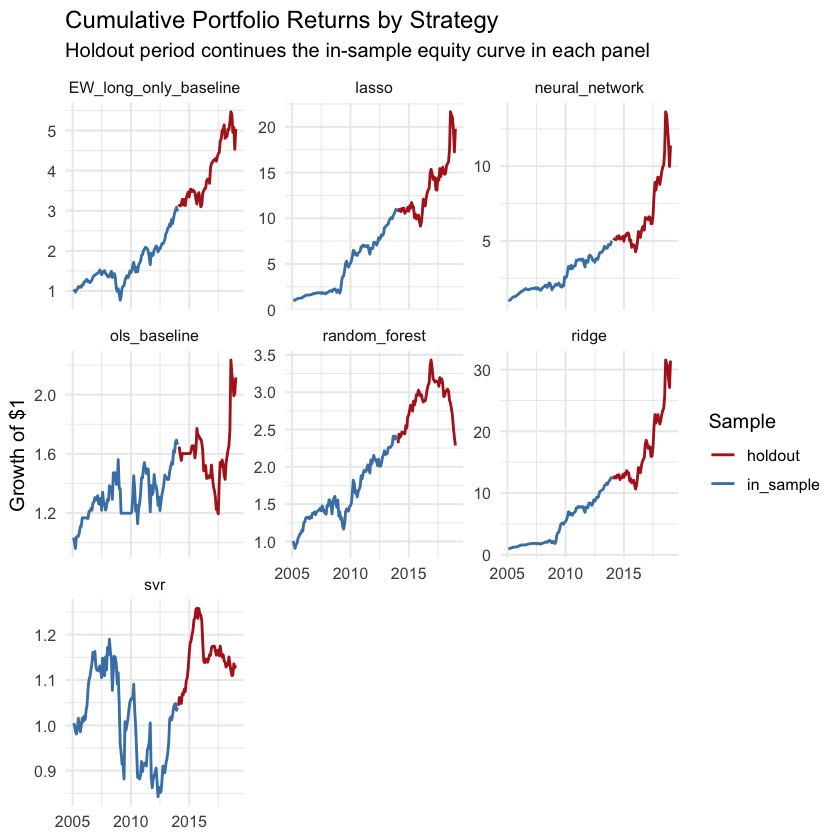

In [110]:
ls_returns_full <- ls_portfolios %>%
  select(strategy, sample, data) %>%
  tidyr::unnest(data) %>%
  arrange(strategy, date) %>%
  group_by(strategy) %>%
  mutate(cumulative_ls = cumprod(1 + ls_return)) %>%
  ungroup()

ggplot(ls_returns_full, aes(x = date, y = cumulative_ls, color = sample)) +
  geom_line(linewidth = 0.8) +
  facet_wrap(~ strategy, scales = "free_y") +
  labs(
    title = "Cumulative Portfolio Returns by Strategy",
    subtitle = "Holdout period continues the in-sample equity curve in each panel",
    x = NULL,
    y = "Growth of $1",
    color = "Sample"
  ) +
  scale_color_manual(values = c(in_sample = "steelblue", holdout = "firebrick")) +
  theme_minimal(base_size = 12)


## Full-Period Strategy Comparison

This chart overlays the cumulative portfolio performance of every strategy over the full evaluation period so we can compare the path of returns directly on one set of axes.


Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”
Warning message in scale_x_date():
“A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.”


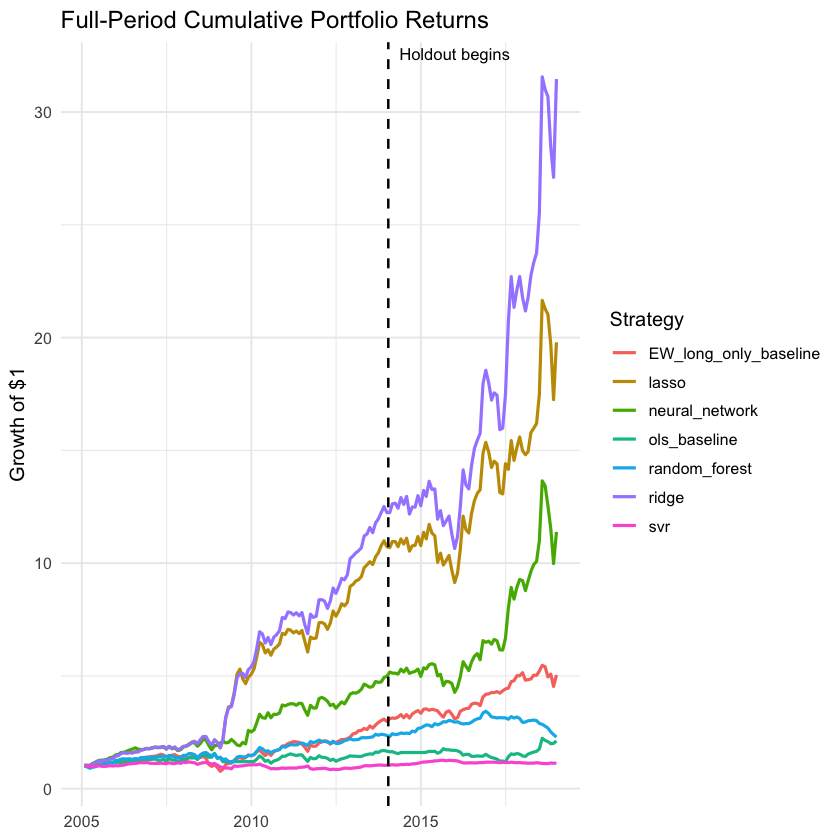

In [111]:
p <- ggplot(ls_returns_full, aes(x = date, y = cumulative_ls, color = strategy)) +
  geom_line(linewidth = 0.9) +
  geom_vline(
    xintercept = as.numeric(HOLDOUT_START),
    linetype = "dashed",
    color = "black",
    linewidth = 0.7
  ) +
  annotate(
    "text",
    x = HOLDOUT_START,
    y = Inf,
    label = "Holdout begins",
    vjust = 1.5,
    hjust = -0.1,
    size = 3.5,
    color = "black"
  ) +
  labs(
    title = "Full-Period Cumulative Portfolio Returns",
    # subtitle = "Continuous equity curves for all evaluated strategies and the equal-weight baseline",
    x = NULL,
    y = "Growth of $1",
    color = "Strategy"
  ) +
  theme_minimal(base_size = 12)

ggsave("equity_curve.png", plot = p, width = 10, height = 5, dpi = 300)

p

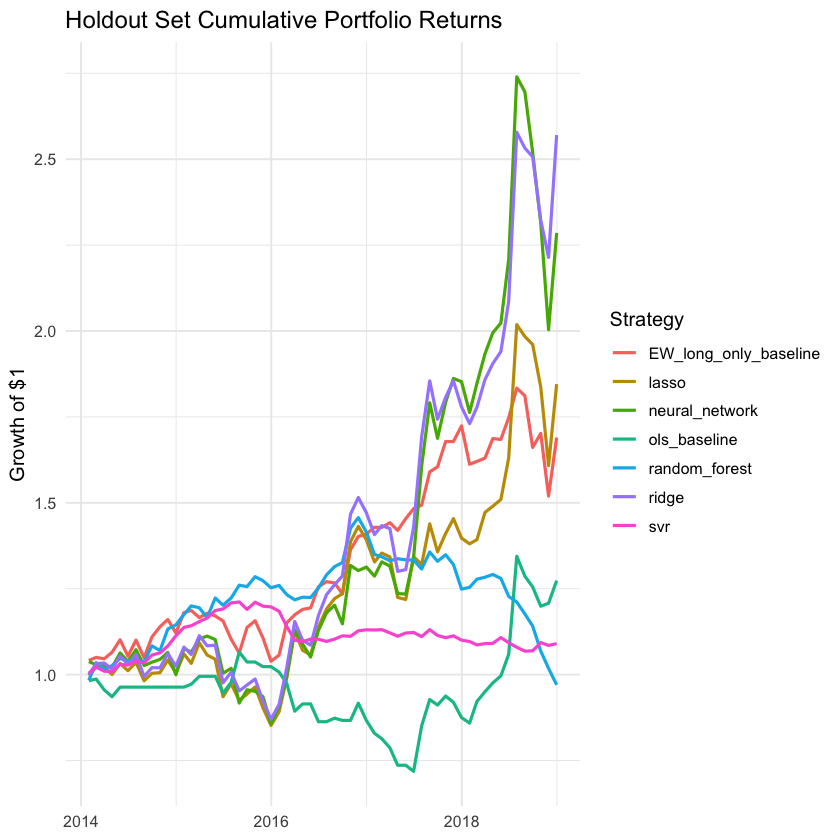

In [116]:
holdout_plot_start <- lubridate::ceiling_date(HOLDOUT_START, "month") - lubridate::days(1)

# reindex returns so all strategies starts at $1 at holdout start date
ls_returns_holdout <- ls_portfolios %>%
  select(strategy, sample, data) %>%
  tidyr::unnest(data) %>%
  filter(date >= holdout_plot_start) %>%
  arrange(strategy, date) %>%
  group_by(strategy) %>%
  mutate(cumulative_ls = cumprod(1 + ls_return)) %>%
  ungroup()

p <- ggplot(ls_returns_holdout, aes(x = date, y = cumulative_ls, color = strategy)) +
  geom_line(linewidth = 0.9) +
  labs(
    title = "Holdout Set Cumulative Portfolio Returns",
    x = NULL,
    y = "Growth of $1",
    color = "Strategy"
  ) +
  theme_minimal(base_size = 12)

ggsave("equity_curve_holdout.png", plot = p, width = 10, height = 5, dpi = 300)

p


In [112]:
ff5_summary_for_join <- if (exists("ff5_model_summary")) {
  ff5_model_summary %>%
    select(strategy, sample, alpha_monthly, alpha_annualised, alpha_monthly_tc, alpha_annualised_tc, r_squared, adj_r_squared, r_squared_tc, adj_r_squared_tc)
} else {
  tibble(
    strategy = character(),
    sample = character(),
    alpha_monthly = numeric(),
    alpha_annualised = numeric(),
    alpha_monthly_tc = numeric(),
    alpha_annualised_tc = numeric(),
    r_squared = numeric(),
    adj_r_squared = numeric(),
    r_squared_tc = numeric(),
    adj_r_squared_tc = numeric()
  )
}

strategy_performance_summary <- prediction_metrics %>%
  full_join(portfolio_metrics, by = c("strategy", "sample")) %>%
  full_join(ff5_summary_for_join, by = c("strategy", "sample")) %>%
  arrange(sample, strategy)


In [113]:
strategy_performance_summary

strategy,sample,observations,mse,hit_ratio,oos_r2,months,avg_turnover,avg_monthly_return,avg_monthly_return_tc,⋯,sharpe_tc,sharpe_tc_ann,alpha_monthly,alpha_annualised,alpha_monthly_tc,alpha_annualised_tc,r_squared,adj_r_squared,r_squared_tc,adj_r_squared_tc
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EW_long_only_baseline,holdout,NA,NA,NA,NA,60,0.06381047,0.0096171549,0.0096171549,⋯,0.233100636,0.80748429,0.010445852,0.12535022,0.010445852,0.12535022,0.14240399,0.062996956,0.14240399,0.062996956
lasso,holdout,70208,0.03702010,0.5320334,-0.0011841520,60,0.81938309,0.0121679604,0.0121679604,⋯,0.191735841,0.66419244,0.010289644,0.12347573,0.010289644,0.12347573,0.06704127,-0.019343796,0.06704127,-0.019343796
neural_network,holdout,70208,0.03706859,0.5460346,-0.0024955273,60,0.73329398,0.0162103589,0.0162103589,⋯,0.230062324,0.79695927,0.013542137,0.16250564,0.013542137,0.16250564,0.06264088,-0.024151627,0.06264088,-0.024151627
ols_baseline,holdout,70173,0.08623668,0.5280949,-1.3314509469,60,1.23787390,0.0054076433,0.0054076433,⋯,0.098361065,0.34073272,0.005385683,0.06462819,0.005385683,0.06462819,0.02541591,-0.064823353,0.02541591,-0.064823353
random_forest,holdout,70173,0.04069083,0.5280949,-0.1000966567,60,2.25338848,-0.0001176230,-0.0001176230,⋯,-0.004192355,-0.01452274,-0.001946387,-0.02335664,-0.001946387,-0.02335664,0.08626494,0.001659845,0.08626494,0.001659845
ridge,holdout,70208,0.03701457,0.5315491,-0.0010345615,60,0.71074360,0.0178922270,0.0178922270,⋯,0.270953919,0.93861191,0.015864256,0.19037107,0.015864256,0.19037107,0.04736209,-0.040845123,0.04736209,-0.040845123
svr,holdout,70208,0.03817041,0.5416762,-0.0322935653,60,1.84876647,0.0015254695,0.0015254695,⋯,0.116284373,0.40282089,0.001269999,0.01523998,0.001269999,0.01523998,0.08320671,-0.001681554,0.08320671,-0.001681554
EW_long_only_baseline,in_sample,NA,NA,NA,NA,108,0.06670844,0.0119875491,0.0119875491,⋯,0.198558847,0.68782802,0.013012303,0.15614763,0.013012303,0.15614763,0.08892504,0.044264498,0.08892504,0.044264498
lasso,in_sample,128880,0.02771542,0.5362042,-0.0001636182,108,0.71981365,0.0243134921,0.0243134921,⋯,0.351757997,1.21852545,0.022873574,0.27448288,0.022873574,0.27448288,0.04297027,-0.003942949,0.04297027,-0.003942949
